### [Exploring Multivariate Analysis in Financial Econometrics](https://medium.com/@simplifiedzone/exploring-multivariate-analysis-in-financial-econometrics-8a2ab1828ffa)

##### **Linear Correlation (Pearson)**

Pearson correlation measures the strength of the Linear Relationship between two variables.

- **+1**: Perfect positive linear relationship.
- **-1**: Perfect negative linear relationship.
- **0**: No linear relationship.

##### **Rank Correlations**

- **Spearman’s Rho ($\rho_s$)**: This is simply the Pearson correlation calculated on the ranks of the data rather than the raw values.

- **Kendall’s Tau ($tau$)**: Kendall's Tau is often preferred for smaller datasets or when hypothesis testing is critical. It is based on Concordance.

If $tau = 1$, the rankings are identical. If $tau = -1$, one ranking is the reverse of the other.

###### **Joint Probability**

Correlation reduces the relationship between two assets to a single number. Joint Probability Distributions gives the full map.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

import warnings
warnings.filterwarnings('ignore')

In [2]:
def load_data(filepath):
    """
    Loads data and selects Dow Jones (DWJ) and 10Y Treasury Bond Yields (10Y_TBY).
    """
    try:
        df = pd.read_csv(filepath)
        # Select relevant columns and drop NaNs
        # We use 10Y_TBY to see the relationship between Equities and Rates
        data = df[['DWJ', '10Y_TBY']].dropna()
        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def analyze_correlations(data):
    """
    Calculates and compares Pearson, Spearman, and Kendall correlations.
    """
    pearson = data.corr(method='pearson').iloc[0, 1]
    spearman = data.corr(method='spearman').iloc[0, 1]
    kendall = data.corr(method='kendall').iloc[0, 1]

    print("\n--- Correlation Analysis (DWJ vs 10Y_TBY) ---")
    print(f"Pearson (Linear):   {pearson:.4f}")
    print(f"Spearman (Rank):    {spearman:.4f}")
    print(f"Kendall (Tau):      {kendall:.4f}")

    return pearson, spearman, kendall

def visualize_joint_distribution(data):
    """
    Visualizes the Joint Distribution using a Kernel Density Estimate (KDE).
    This shows where the 'mass' of the data is concentrated.
    """
    g = sns.jointplot(x='DWJ', y='10Y_TBY', data=data, kind="kde", fill=True, cmap="Blues")
    g.fig.suptitle('Joint Distribution: DWJ vs 10Y Treasury Yields', y=1.02)
    plt.show()

def visualize_copula_transform(data):
    """
    Demonstrates the Probability Integral Transform (PIT).
    Converts raw returns into Uniform[0,1] values to visualize the Empirical Copula.
    """
    # Rank data and normalize to (0, 1)
    # This removes the marginal distribution shape (bell curve) and leaves only the dependence structure
    u_dwj = stats.rankdata(data['DWJ']) / (len(data) + 1)
    u_10y = stats.rankdata(data['10Y_TBY']) / (len(data) + 1)

    plt.figure(figsize=(10, 10))
    plt.scatter(u_dwj, u_10y, alpha=0.2, s=10, color='darkgreen')
    plt.title('Empirical Copula (Pseudo-Observations)\nData Transformed to Uniform Scale [0,1]')
    plt.xlabel('DWJ (Uniform Quantile)')
    plt.ylabel('10Y_TBY (Uniform Quantile)')
    plt.axhline(0.5, color='gray', linestyle='--')
    plt.axvline(0.5, color='gray', linestyle='--')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

def calculate_tail_dependence(data, quantile=0.05):
    """
    Estimates Lower Tail Dependence:
    P(Y < q | X < q) = P(X < q and Y < q) / P(X < q)
    """
    # Define threshold values
    q_dwj = data['DWJ'].quantile(quantile)
    q_10y = data['10Y_TBY'].quantile(quantile)

    # Count occurrences
    both_crash = len(data[(data['DWJ'] < q_dwj) & (data['10Y_TBY'] < q_10y)])
    dwj_crash = len(data[data['DWJ'] < q_dwj])

    if dwj_crash == 0:
        tail_dep = 0
    else:
        tail_dep = both_crash / dwj_crash

    print(f"\n--- Empirical Lower Tail Dependence (q={quantile}) ---")
    print(f"Probability of 10Y Yield dropping significantly GIVEN Dow Jones drops significantly: {tail_dep:.2%}")


--- Correlation Analysis (DWJ vs 10Y_TBY) ---
Pearson (Linear):   0.4042
Spearman (Rank):    0.3386
Kendall (Tau):      0.2399


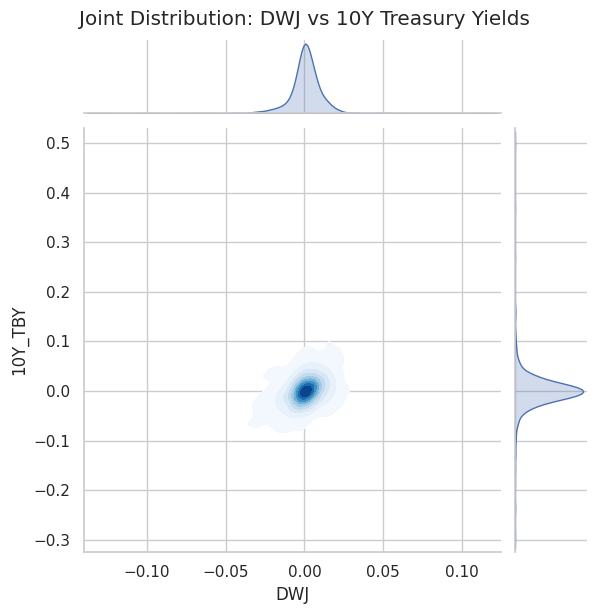

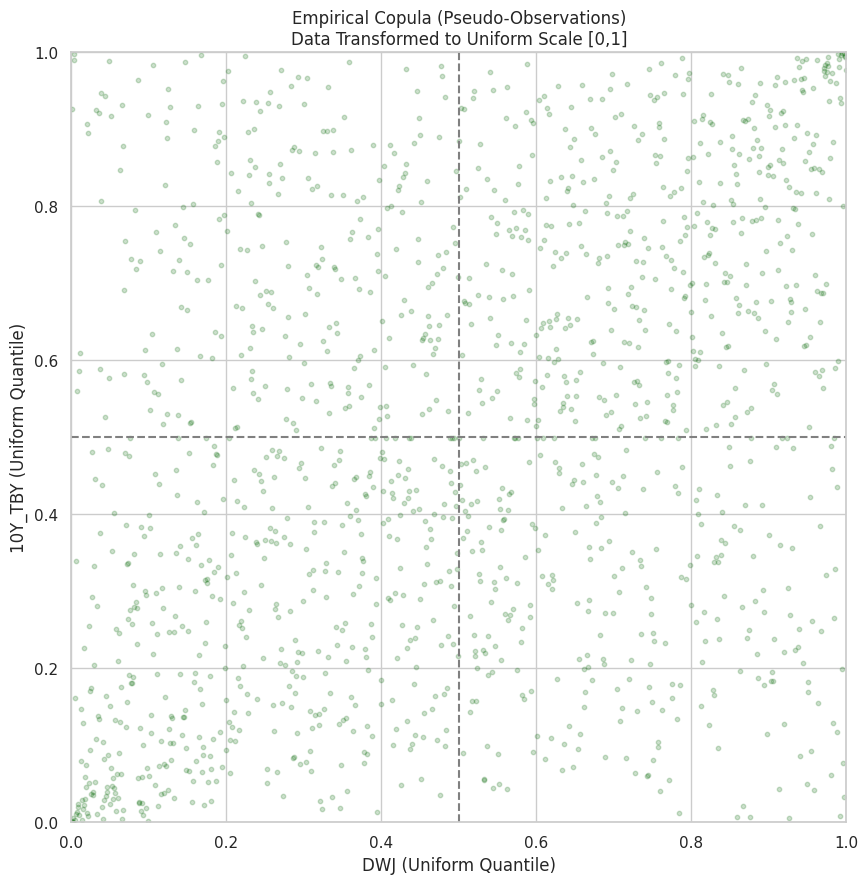


--- Empirical Lower Tail Dependence (q=0.05) ---
Probability of 10Y Yield dropping significantly GIVEN Dow Jones drops significantly: 36.84%


In [3]:
if __name__ == "__main__":
    file_path = '/content/data.csv'

    df_clean = load_data(file_path)

    if df_clean is not None:
        analyze_correlations(df_clean)
        visualize_joint_distribution(df_clean)
        visualize_copula_transform(df_clean)
        calculate_tail_dependence(df_clean)